# Clinical Triage Supervisor Agent (fixed)

This is a corrected version of `supervise_agent.ipynb`. Fixes applied, all marked with `# FIXED:` comments:

1. `t_llm` → `llm_with_tools` (undefined variable that would crash the intake agent).
2. `Superviser` schema now inherits `BaseModel` (not `MessagesState`, which is a TypedDict) and uses `description=` instead of the typo `discription=`.
3. `with_structured_output(router)` → `with_structured_output(Superviser)` — a function was being passed where a schema was required.
4. All node names, the `Superviser` routing `Literal`, and the supervisor's prompt now use **exactly the same strings** (`validation_agent`, `cardio_ml_worker`, `reporting_worker`, `FINISH`) — previously they didn't match, which would have caused a `KeyError` at routing time.
5. Added a `report_generated` flag to state so the supervisor has an explicit, deterministic way to reach `FINISH` instead of looping between `reporting_worker` and the supervisor forever.
6. Supervisor prompt now reasons over the structured `state` fields directly instead of asking the LLM to re-infer them from free-text conversation history.
7. Fixed the final results loop — it used `msg.role`, which doesn't exist on LangChain message objects (it's `msg.type`); it now handles both message objects and plain dicts.
8. Safer environment-variable loading (won't crash with `TypeError` if `LANGSMITH_API_KEY`/`LANGSMITH_PROJECT` are unset).
9. Renamed the tool-vs-supervisor conditional-edge function from `router` to `tool_call_router` so it's no longer confusable with the `Superviser` routing schema.


In [101]:
import os
import math
from typing import Literal, Dict, Any
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain_core.messages import HumanMessage, BaseMessage
from langgraph.prebuilt import ToolNode
from langchain_core.tools import tool
from dotenv import load_dotenv
from langchain_groq import  ChatGroq


In [102]:
load_dotenv()

# FIXED: guard against os.environ[...] = None crashing (TypeError) if the
# env vars aren't set. Only set them when a value actually exists.
os.environ["LANGCHAIN_TRACING_V2"] = "true"

_langsmith_key = os.getenv("LANGSMITH_API_KEY")
if _langsmith_key:
    os.environ["LANGCHAIN_API_KEY"] = _langsmith_key

_langsmith_project = os.getenv("LANGSMITH_PROJECT")
if _langsmith_project:
    os.environ["LANGCHAIN_PROJECT"] = _langsmith_project

# CHANGED: Groq instead of Hugging Face.
# Reads your key from GROQ_API_KEY in .env (get one at
# https://console.groq.com/keys).
#
# NOTE: llama-3.3-70b-versatile was deprecated by Groq on 2026-08-16.
# openai/gpt-oss-120b is their recommended replacement and supports both
# tool calling and structured output, which this graph relies on.
_groq_key = os.getenv("GROQ_API_KEY")
if not _groq_key:
    raise ValueError("GROQ_API_KEY is not set. Add it to your .env file.")

llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0,  # deterministic routing, same intent as do_sample=False before
    api_key=_groq_key,
)


In [103]:
class Clinical_state(MessagesState):
    patient_vitals: Dict[str, Any]
    risk_score: float
    next_node: str
    # FIXED: added so the supervisor has a deterministic way to know the
    # workflow is actually finished, instead of looping forever.
    report_generated: bool


In [104]:
# FIXED: Superviser now inherits BaseModel (a real Pydantic model), not
# MessagesState (which is a TypedDict and doesn't support Field() metadata
# the way with_structured_output expects). Also fixed "discription" -> "description".
class Superviser(BaseModel):
    """The supervisor decides which worker should run next."""
    next_node: Literal["validation_agent", "cardio_ml_worker", "reporting_worker", "FINISH"] = Field(
        description="Route to validation_agent if vitals are missing, cardio_ml_worker if data "
                     "is ready but risk hasn't been scored, reporting_worker if risk is scored "
                     "but no report exists yet, or FINISH once the report has been generated.")


In [105]:
@tool
def vec_db(patient: str) -> str:
    """Search vector database for historical patient vitals."""
    rec = {
        "khan": "Historical vitals: age 55, previous cholesterol 245, max heart rate 140.",
        "azmat": "Historical vitals: age 42, previous cholesterol 190, max heart rate 165."
    }
    return rec.get(patient, "no rec found")


@tool
def search_clinical_literature(symptom: str) -> str:
    """Query external literature for symptom risk factors."""
    if "chest pain" in symptom.lower():
        return "Literature indicates atypical angina combined with cholesterol > 240 increases risk."
    return "No significant recent literature flags for this symptom."


tools = [vec_db, search_clinical_literature]
llm_with_tools = llm.bind_tools(tools)


In [106]:
# react agent and routing

def react_Agent(state: Clinical_state):
    sys_prompt = (
        "You are a clinical intake agent. Use tools to gather full patient history. "
        "Once you have gathered the data, summarize it and stop using tools.")
    messages = [{"role": "system", "content": sys_prompt}] + state["messages"]

    # FIXED: t_llm was never defined anywhere -> NameError. The bound-tools
    # model built above is llm_with_tools.
    resp = llm_with_tools.invoke(messages)

    return {"messages": [resp]}


# FIXED: renamed from `router` to `tool_call_router` to avoid confusion with
# the Superviser structured-output schema used in supervisor_node below --
# the original code accidentally passed this function where a schema was
# expected because both things were called "router".
def tool_call_router(state: Clinical_state) -> Literal["tools", "supervisor_node"]:
    lastmsg = state["messages"][-1]

    # Safely check if the attribute exists before trying to read it
    if hasattr(lastmsg, "tool_calls") and lastmsg.tool_calls:
        return "tools"

    return "supervisor_node"


In [107]:
def supervisor_node(state: Clinical_state):
    # FIXED: give the supervisor the structured state directly instead of
    # asking the LLM to re-derive it from free-text messages, and give it an
    # explicit FINISH condition (report_generated) so the graph can actually
    # terminate instead of looping reporting_worker -> supervisor forever.
    vitals = state.get("patient_vitals", {})
    risk_score = state.get("risk_score", 0.0)
    report_generated = state.get("report_generated", False)

    sys_prompt = (
        "You are the Clinical Triage Supervisor. Decide the next step using ONLY the "
        "structured state below.\n\n"
        f"- patient_vitals: {vitals}\n"
        f"- risk_score: {risk_score}\n"
        f"- report_generated: {report_generated}\n\n"
        "Rules:\n"
        "- If patient_vitals is empty, route to 'validation_agent'.\n"
        "- Else if risk_score == 0.0, route to 'cardio_ml_worker'.\n"
        "- Else if report_generated is False, route to 'reporting_worker'.\n"
        "- Else (report_generated is True), route to 'FINISH'."
    )
    messages = [{"role": "system", "content": sys_prompt}] + state["messages"]

    # FIXED: pass the Superviser schema, not the tool_call_router function.
    decision = llm.with_structured_output(Superviser).invoke(messages)
    return {"next_node": decision.next_node}


def validationagent(state: Clinical_state):
    """Parses text to extract a clean dictionary of features."""
    cleaned_vitals = {"age": 55, "chol": 245, "thalach": 140}
    return {
        "patient_vitals": cleaned_vitals,
        "messages": [{"role": "assistant", "content": "Vitals strictly validated and formatted."}]
    }


def calculate_gauss_prob(x: float, mean: float, stdev: float) -> float:
    """mathematical implementation of the gaussian PDF from scratch"""
    if stdev == 0.0:
        stdev = 1e-9
    exponent = math.exp(-((x - mean) ** 2 / (2 * stdev ** 2)))
    return (1 / (math.sqrt(2 * math.pi) * stdev)) * exponent


def cardio_ml_worker(state: Clinical_state):
    """executes the classical ML prediction pipeline"""
    vitals = state.get("patient_vitals", {})
    age = vitals.get("age", 50)
    chol = vitals.get("chol", 200)
    mean_age, std_age = 54.0, 9.0
    mean_chol, std_chol = 250.0, 40.0
    probage = calculate_gauss_prob(age, mean_age, std_age)
    probchol = calculate_gauss_prob(chol, mean_chol, std_chol)
    risk_score = round(probage * probchol * 1000, 4)
    return {
        "risk_score": risk_score,
        "messages": [{"role": "assistant", "content": f"Gaussian ML risk score calculated: {risk_score}"}]
    }


def reporting_worker(state: Clinical_state):
    """Formats the final payload for the Streamlit UI."""
    vitals = state.get("patient_vitals", {})
    score = state.get("risk_score", 0.0)
    report = f"FINAL DIAGNOSTIC PAYLOAD:\n- Vitals: {vitals}\n- Calculated Gaussian Risk Score: {score}"
    return {
        "messages": [{"role": "assistant", "content": report}],
        # FIXED: this flag is what lets the supervisor route to FINISH next time.
        "report_generated": True,
    }


In [108]:
graph = StateGraph(Clinical_state)


In [109]:
# FIXED: node names below now match, exactly, the Literal values used in
# Superviser and the strings referenced in the supervisor prompt/routing map
# (validation_agent, cardio_ml_worker, reporting_worker). Previously these
# were inconsistent ("validation_Agent", "cardiomlworker", "reportingworker"
# vs "validation_agent", "cardio_ml_worker", "reporting_worker") which would
# have raised a routing error the first time the supervisor tried to act.
graph.add_node("react_agent", react_Agent)
graph.add_node("tools", ToolNode(tools))
graph.add_node("cardio_ml_worker", cardio_ml_worker)
graph.add_node("supervisor_node", supervisor_node)
graph.add_node("reporting_worker", reporting_worker)
graph.add_node("validation_agent", validationagent)


In [110]:
# routing

graph.add_edge(START, "react_agent")
graph.add_conditional_edges(
    "react_agent",
    tool_call_router,
    {"tools": "tools", "supervisor_node": "supervisor_node"},
)

graph.add_edge("tools", "react_agent")


In [111]:
graph.add_edge("validation_agent", "supervisor_node")
graph.add_edge("reporting_worker", "supervisor_node")
graph.add_edge("cardio_ml_worker", "supervisor_node")


In [112]:
graph.add_conditional_edges(
    "supervisor_node",
    lambda state: state["next_node"],
    {
        "validation_agent": "validation_agent",
        "cardio_ml_worker": "cardio_ml_worker",
        "reporting_worker": "reporting_worker",
        "FINISH": END,
    },
)


In [113]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

app = graph.compile(checkpointer=memory)


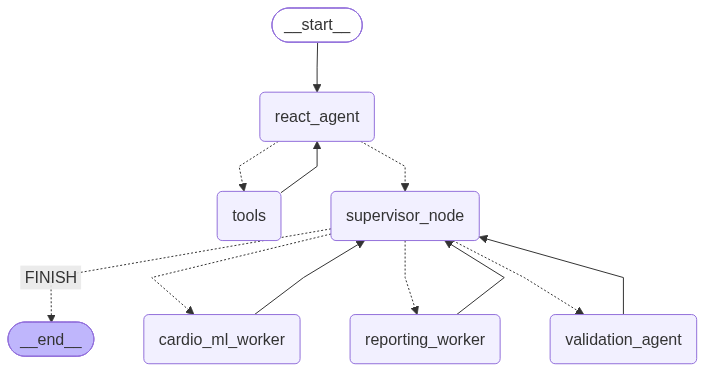

In [114]:
app


In [115]:
initial_input = "Patient khan is experiencing chest pain."
config = {"configurable": {"thread_id": "session-1"}}
result = app.invoke({
    "messages": [HumanMessage(content=initial_input)],
    "patient_vitals": {},
    "risk_score": 0.0,
    "next_node": "",
    "report_generated": False,  # FIXED: initialize the new state field
}, config=config)


# FIXED: BaseMessage objects use `.type`, not `.role` (that attribute
# doesn't exist and would raise AttributeError). Some nodes also emit plain
# dicts with a "role" key rather than message objects, so this handles both.
def _speaker(msg):
    if hasattr(msg, "type"):
        return msg.type
    if isinstance(msg, dict):
        return msg.get("role", "unknown")
    return "unknown"


def _text(msg):
    if hasattr(msg, "content"):
        return msg.content
    if isinstance(msg, dict):
        return msg.get("content", "")
    return str(msg)


for msg in result["messages"]:
    print(f"{_speaker(msg).upper()}: {_text(msg)}\n")


HUMAN: Patient khan is experiencing chest pain.

AI: 

TOOL: Historical vitals: age 55, previous cholesterol 245, max heart rate 140.

AI: 

TOOL: Literature indicates atypical angina combined with cholesterol > 240 increases risk.

AI: Thank you for sharing that information. To help me understand your situation fully, could you please provide details on the following?

1. **Chest pain characteristics**  
   - When did the pain start?  
   - How would you describe the pain (e.g., pressure, sharp, burning, squeezing)?  
   - Is the pain constant or does it come and go?  
   - Does anything make it better or worse (e.g., rest, activity, breathing, position, medication)?

2. **Radiation and associated symptoms**  
   - Does the pain radiate to your arm, jaw, back, or neck?  
   - Are you experiencing shortness of breath, sweating, nausea, light‑headedness, palpitations, or any other symptoms?

3. **Medical history**  
   - Do you have any known heart conditions (e.g., coronary artery dise